# 06 · Validación fuera de muestra (febrero 2015)

Este notebook cubre la **sección 5.3.4** de la práctica: evaluar las rutas $x^\star$ y $x^{prom}$ (ya fijadas en `05_main_experiment.ipynb`) sobre escenarios sintéticos generados a partir de datos **reales de febrero de 2015** — un mes que nunca se usó para entrenar ni elegir ninguna de las dos rutas.

**Reglas estrictas de esta validación (tal como las exige el enunciado):**

- Se repite el procedimiento de la sección 2.3 **exactamente igual**, pero con fechas de pickup de febrero: se incluye el 1 de febrero y se excluye el 1 de marzo.
- Los pools de prueba $\tilde P_{ij}$ **no se mezclan** con los pools de enero — deben aparecer los 110 pares dirigidos, y el pool más pequeño debe tener ≥ 90 registros.
- Se generan $K_{test}=1000$ escenarios de prueba con una **semilla distinta** a las de enero.
- Se mantienen **fijas**: las rutas $x^\star$ y $x^{prom}$, las distancias $d^{road}_{ij}$ y los costos $c_{ij}$ calculados para el problema de entrenamiento (enero) — **no se recalculan con datos de febrero**.
- **No se reoptimiza nada**: solo se resuelven los subproblemas de recurso $Q(x,\tilde\xi^\ell)$ para cada ruta ya fija, sobre los mismos 1000 escenarios de prueba para ambas.

**Entradas:** `../data/raw/yellow_tripdata_2015-02.parquet` (ya debe estar descargado ahí), `data/processed/sites.csv`, `arc_costs.csv` (de enero), `data/processed/main_experiment_K200_results.json` (rutas $x^\star$, $x^{prom}$)
**Salidas:** `results/tables/out_of_sample_february_results.json`

In [1]:
import json
import numpy as np
import pandas as pd
import duckdb
from scipy.optimize import linprog
from pathlib import Path

RAW_DIR = Path("../data/raw")
PROC_DIR = Path("../data/processed")
RESULTS_TABLES = Path("../results/tables")
RESULTS_TABLES.mkdir(parents=True, exist_ok=True)

RAW_FILE_FEB = RAW_DIR / "yellow_tripdata_2015-02.parquet"
assert RAW_FILE_FEB.exists(), (
    f"No se encontró {RAW_FILE_FEB}. Descárguelo desde "
    "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2015-02.parquet "
    "y colóquelo en data/raw/ antes de continuar."
)
print(f"Archivo de febrero encontrado: {RAW_FILE_FEB}")

sites = pd.read_csv(PROC_DIR / "sites.csv")
arc_costs = pd.read_csv(PROC_DIR / "arc_costs.csv")  # costos de ENERO, se mantienen fijos

with open(PROC_DIR / "main_experiment_K200_results.json") as f:
    main_results = json.load(f)

# Reconstruir x_star y x_prom como diccionarios {(i,j): 0/1} a partir del JSON guardado
def unpack_route_dict(d):
    return {tuple(int(p) for p in k.split("_")): v for k, v in d.items()}

x_star = unpack_route_dict(main_results["x_star"])
x_prom = unpack_route_dict(main_results["x_prom"])

V = sites["i"].tolist()
N = [i for i in V if i != 0]
A = list(x_star.keys())
n = len(N)
c_ij = {(row.i, row.j): row.c_ij for row in arc_costs.itertuples()}

H = 390.0; o_bar = 30.0; c_OT = 1.50; c_EM = 6.00
alpha = {i: 1.0 for i in N}

demand_cost = pd.DataFrame([
    {"i": 1,  "d_i": 30, "c_out_i": 2.60},{"i": 2,  "d_i": 30, "c_out_i": 2.40},
    {"i": 3,  "d_i": 35, "c_out_i": 2.80},{"i": 4,  "d_i": 30, "c_out_i": 2.30},
    {"i": 5,  "d_i": 25, "c_out_i": 2.10},{"i": 6,  "d_i": 25, "c_out_i": 2.00},
    {"i": 7,  "d_i": 35, "c_out_i": 2.70},{"i": 8,  "d_i": 40, "c_out_i": 3.00},
    {"i": 9,  "d_i": 35, "c_out_i": 2.90},{"i": 10, "d_i": 25, "c_out_i": 2.20},
]).set_index("i")
d_i = demand_cost["d_i"].to_dict()
c_out_i = demand_cost["c_out_i"].to_dict()

print(f"x* y x_prom cargadas. ¿Son la misma ruta?: {main_results['routes_identical']}")


Archivo de febrero encontrado: ../data/raw/yellow_tripdata_2015-02.parquet
x* y x_prom cargadas. ¿Son la misma ruta?: True


## 1. Filtros y pools de prueba (repite la sección 2.3, con fechas de febrero)

Idénticos criterios que en `01_pools_and_qc.ipynb`, cambiando únicamente el rango de fechas: pickup entre el **1 de febrero (inclusive)** y el **1 de marzo (exclusive)**.

In [2]:
location_to_i = dict(zip(sites["location_id"], sites["i"]))
location_ids = tuple(sites["location_id"].tolist())

query = f"""
SELECT
    PULocationID,
    DOLocationID,
    trip_distance,
    date_diff('second', tpep_pickup_datetime, tpep_dropoff_datetime) / 60.0 AS duration_min,
    dayofweek(tpep_pickup_datetime) AS dow,
    hour(tpep_pickup_datetime) AS pickup_hour
FROM read_parquet('{RAW_FILE_FEB.as_posix()}')
WHERE tpep_pickup_datetime >= TIMESTAMP '2015-02-01 00:00:00'
  AND tpep_pickup_datetime <  TIMESTAMP '2015-03-01 00:00:00'
  AND PULocationID IN {location_ids}
  AND DOLocationID IN {location_ids}
  AND PULocationID != DOLocationID
"""

raw_feb = duckdb.sql(query).df()
print(f"Registros tras filtro de zonas/fecha bruta (febrero): {len(raw_feb):,}")


Registros tras filtro de zonas/fecha bruta (febrero): 708,559


In [3]:
mask_weekday = raw_feb["dow"].between(1, 5)
mask_hour = raw_feb["pickup_hour"].between(9, 16)
mask_duration = raw_feb["duration_min"].between(1, 90)
mask_distance = raw_feb["trip_distance"].between(0.1, 30)

filtered_feb = raw_feb[mask_weekday & mask_hour & mask_duration & mask_distance].copy()
print(f"Registros tras todos los filtros (febrero): {len(filtered_feb):,}")

filtered_feb["i"] = filtered_feb["PULocationID"].map(location_to_i)
filtered_feb["j"] = filtered_feb["DOLocationID"].map(location_to_i)
filtered_feb = filtered_feb.dropna(subset=["i", "j"]).astype({"i": int, "j": int})
filtered_feb.head()


Registros tras todos los filtros (febrero): 252,935


,PULocationID,DOLocationID,trip_distance,duration_min,dow,pickup_hour,i,j
21064,186,246,0.80,5.700000,1,9,7,0
21065,186,161,1.10,7.383333,1,9,7,2
21066,164,246,1.20,12.433333,1,9,4,0
21067,230,234,1.43,11.633333,1,9,1,5
21068,234,246,1.70,13.683333,1,9,5,0


## 2. Control de calidad de los pools de febrero

Deben aparecer los 110 pares dirigidos, y el pool más pequeño debe tener ≥ 90 registros (según el enunciado, con estos filtros el pool de febrero más pequeño tiene 90 registros exactamente).

In [4]:
pool_counts_feb = (
    filtered_feb.groupby(["i", "j"]).size().reset_index(name="n_trips").sort_values("n_trips")
)

n_arcs_present_feb = len(pool_counts_feb)
print(f"Arcos con al menos 1 registro (febrero): {n_arcs_present_feb} / 110")
print(f"Tamaño mínimo de pool (febrero): {pool_counts_feb['n_trips'].min()}")

assert n_arcs_present_feb == 110, "No aparecen los 110 pares dirigidos esperados en febrero."
assert pool_counts_feb["n_trips"].min() >= 90, "Algún pool de febrero tiene menos de 90 registros."

pools_feb_dict = {
    (i, j): grp["duration_min"].to_numpy()
    for (i, j), grp in filtered_feb.groupby(["i", "j"])
}
print("\nControl de calidad de pools de febrero: OK.")


Arcos con al menos 1 registro (febrero): 110 / 110
Tamaño mínimo de pool (febrero): 90

Control de calidad de pools de febrero: OK.


## 3. Generar $K_{test}=1000$ escenarios de prueba

Muestreo con reemplazo, independiente entre arcos, desde la distribución empírica de los pools de **febrero** — con una semilla **distinta** a las usadas para enero (sección 2.4 y 5.3.4).

In [5]:
SEED_FEB_TEST = 2015  # semilla distinta a SEED_K50=42 y SEED_K200=202 (notebook 02)
K_TEST = 1000

rng = np.random.default_rng(SEED_FEB_TEST)
xi_test = {}
for ell in range(K_TEST):
    xi_test[ell] = {a: rng.choice(pools_feb_dict[a]) for a in A}

print(f"Generados {K_TEST} escenarios de prueba de febrero.")
print(f"Ejemplo escenario 0, arco {A[0]}: {xi_test[0][A[0]]:.2f} min")


Generados 1000 escenarios de prueba de febrero.
Ejemplo escenario 0, arco (0, 1): 10.17 min


## 4. Evaluar ambas rutas (fijas, sin reoptimizar) sobre los 1000 escenarios

$$\hat C_{Feb}(x) = \sum_{(i,j)\in A} c_{ij}x_{ij} + \frac{1}{1000}\sum_{\ell=1}^{1000} Q(x,\tilde\xi^{\ell})$$

Se usa la **misma** función de subproblema (scipy) ya validada en los notebooks 4 y 5. Los costos $c_{ij}$ son los de **enero** (fijos, no se recalculan).

In [6]:
def solve_subproblem(x_fixed: dict, xi_ell: dict):
    T_x = sum(xi_ell[a] * x_fixed[a] for a in A)
    B = H - T_x
    c = [-c_out_i[i] for i in N] + [c_OT, c_EM]
    A_ub = [[alpha[i] for i in N] + [-1, -1]]
    b_ub = [B]
    bounds = [(0, d_i[i]) for i in N] + [(0, o_bar), (0, None)]
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    const = sum(c_out_i[i] * d_i[i] for i in N)
    obj = const + res.fun
    w_vals = res.x[:len(N)]
    o_val, e_val = res.x[len(N)], res.x[len(N) + 1]
    return obj, w_vals, o_val, e_val


def evaluate_route_on_scenarios(x_fixed: dict, scenarios_dict: dict, K_eval: int):
    """Evalúa una ruta fija sobre K_eval escenarios, SIN reoptimizar el ruteo.
    Retorna: (costos por escenario Cℓ(x), frecuencias de uso de recurso)."""
    first_stage = sum(c_ij[a] * x_fixed[a] for a in A)
    C_ell = np.zeros(K_eval)
    freq_o, freq_e, freq_r = 0, 0, 0
    for ell in range(K_eval):
        Q_val, w_vals, o_val, e_val = solve_subproblem(x_fixed, scenarios_dict[ell])
        C_ell[ell] = first_stage + Q_val
        if o_val > 1e-6:
            freq_o += 1
        if e_val > 1e-6:
            freq_e += 1
        if any((d_i[i] - w_vals[k]) > 1e-6 for k, i in enumerate(N)):
            freq_r += 1
    freqs = {"overtime": freq_o / K_eval, "emergency": freq_e / K_eval, "outsourcing": freq_r / K_eval}
    return C_ell, freqs

C_ell_star, freqs_star = evaluate_route_on_scenarios(x_star, xi_test, K_TEST)
C_ell_prom, freqs_prom = evaluate_route_on_scenarios(x_prom, xi_test, K_TEST)

C_hat_Feb_star = C_ell_star.mean()
C_hat_Feb_prom = C_ell_prom.mean()
Delta_Feb = C_hat_Feb_prom - C_hat_Feb_star

print(f"C_hat_Feb(x*):    {C_hat_Feb_star:.4f}")
print(f"C_hat_Feb(x_prom): {C_hat_Feb_prom:.4f}")
print(f"Delta_Feb = C_hat_Feb(x_prom) - C_hat_Feb(x*) = {Delta_Feb:.4f}")


C_hat_Feb(x*):    70.9173
C_hat_Feb(x_prom): 70.9173
Delta_Feb = C_hat_Feb(x_prom) - C_hat_Feb(x*) = 0.0000


## 5. Diferencias pareadas e intervalo de confianza al 95%

$$D_\ell := C_\ell(x^{prom}) - C_\ell(x^\star), \qquad \bar D \pm 1.96\,\frac{s_D}{\sqrt{1000}}$$

Al usar los **mismos** 1000 escenarios para ambas rutas, la comparación es pareada — esto reduce la varianza de la estimación frente a usar muestras de prueba independientes para cada ruta.

In [7]:
D_ell = C_ell_prom - C_ell_star
D_bar = D_ell.mean()
s_D = D_ell.std(ddof=1)
se_D = s_D / np.sqrt(K_TEST)
ci_lower = D_bar - 1.96 * se_D
ci_upper = D_bar + 1.96 * se_D

print(f"D_bar (diferencia media pareada): {D_bar:.4f}")
print(f"s_D (desviación estándar de las diferencias): {s_D:.4f}")
print(f"Error estándar: {se_D:.4f}")
print(f"Intervalo de confianza 95%: [{ci_lower:.4f}, {ci_upper:.4f}]")

if ci_lower > 0:
    print("\n>>> El intervalo NO incluye 0 y es positivo: x* es significativamente mejor que x_prom fuera de muestra.")
elif ci_upper < 0:
    print("\n>>> El intervalo NO incluye 0 y es negativo: x_prom resultó significativamente mejor que x* fuera de muestra.")
else:
    print("\n>>> El intervalo SÍ incluye 0: no hay evidencia estadísticamente significativa de que una ruta")
    print("    sea mejor que la otra fuera de muestra, a pesar de que Delta_Feb puntual pueda favorecer a una.")


D_bar (diferencia media pareada): 0.0000
s_D (desviación estándar de las diferencias): 0.0000
Error estándar: 0.0000
Intervalo de confianza 95%: [0.0000, 0.0000]

>>> El intervalo SÍ incluye 0: no hay evidencia estadísticamente significativa de que una ruta
    sea mejor que la otra fuera de muestra, a pesar de que Delta_Feb puntual pueda favorecer a una.


## 6. Frecuencias de uso de recurso (fuera de muestra, febrero)

In [8]:
print("Frecuencias de uso de recurso (fuera de muestra, K_test=1000, febrero):")
print(f"{'':20s} {'x*':>10s} {'x_prom':>10s}")
print(f"{'Tiempo adicional':20s} {freqs_star['overtime']:>10.1%} {freqs_prom['overtime']:>10.1%}")
print(f"{'Emergencia':20s} {freqs_star['emergency']:>10.1%} {freqs_prom['emergency']:>10.1%}")
print(f"{'Tercerización':20s} {freqs_star['outsourcing']:>10.1%} {freqs_prom['outsourcing']:>10.1%}")


Frecuencias de uso de recurso (fuera de muestra, K_test=1000, febrero):
                             x*     x_prom
Tiempo adicional          99.2%      99.2%
Emergencia                 0.0%       0.0%
Tercerización             51.5%      51.5%


## 7. Comparación de distribuciones enero vs. febrero (arcos relevantes)

Se comparan las distribuciones empíricas de tiempos de viaje entre enero (entrenamiento) y febrero (prueba) para algunos arcos — útil para la figura de la sección 6 del enunciado y para discutir en las preguntas de interpretación si hubo un cambio sustancial en el tráfico entre los dos meses.

¿x* y x_prom son la misma ruta?: True
Arcos seleccionados para comparar enero vs. febrero: [(0, 7), (2, 3), (4, 5), (6, 10)]


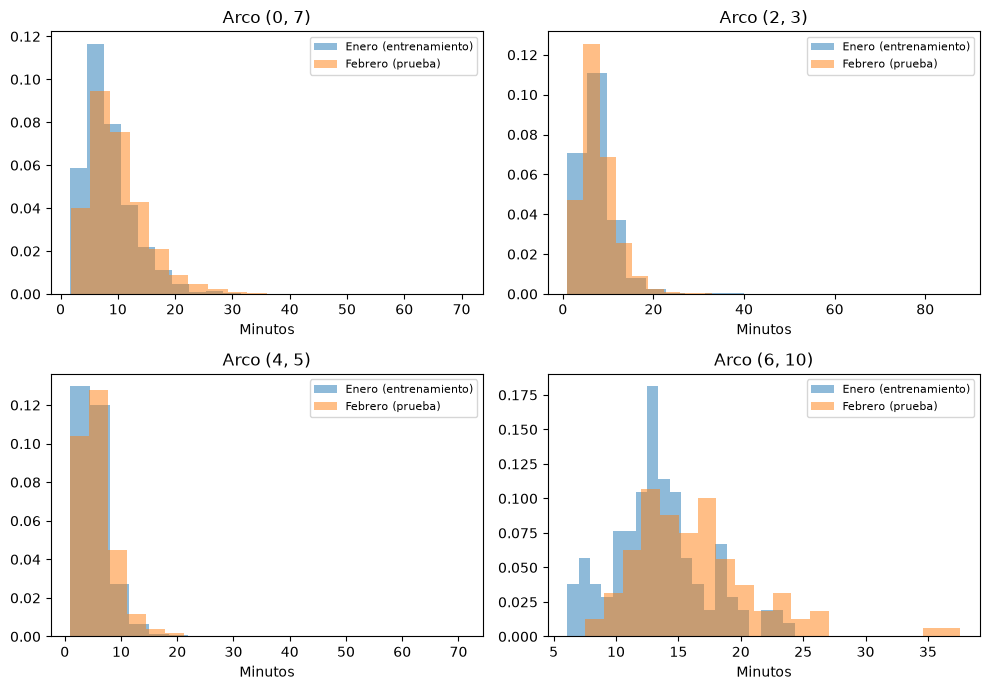

,arco,media_enero,media_febrero,std_enero,std_febrero
0,0->7,8.491683,10.081472,4.554598,5.172262
1,2->3,7.552943,7.929469,4.323457,4.304367
2,4->5,5.333847,6.021824,2.984058,3.564896
3,6->10,13.413333,16.368868,3.785324,4.991273


In [9]:
import matplotlib.pyplot as plt

pools_jan = pd.read_parquet(PROC_DIR / "pools.parquet")
pools_jan_dict = {(i, j): grp["t"].to_numpy() for (i, j), grp in pools_jan.groupby(["i", "j"])}

# Arcos más usados por x* o x_prom (más relevantes para el análisis que arcos arbitrarios).
# Si x* y x_prom son la misma ruta (ver notebook 05), ambos conjuntos de arcos son
# idénticos; en ese caso tomamos 4 arcos DISTINTOS de esa única ruta, distribuidos a
# lo largo del recorrido (inicio, medio, fin) para una comparación más representativa
# que solo los primeros dos.
arcs_star = [a for a in A if x_star[a] > 0.5]
arcs_prom = [a for a in A if x_prom[a] > 0.5]

if main_results["routes_identical"]:
    # tomar 4 arcos espaciados a lo largo de la ruta única
    step = max(1, len(arcs_star) // 4)
    relevant_arcs = arcs_star[::step][:4]
else:
    relevant_arcs = list(dict.fromkeys(arcs_star[:2] + arcs_prom[:2]))[:4]

print(f"¿x* y x_prom son la misma ruta?: {main_results['routes_identical']}")
print(f"Arcos seleccionados para comparar enero vs. febrero: {relevant_arcs}")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, a in zip(axes.flat, relevant_arcs):
    ax.hist(pools_jan_dict[a], bins=20, alpha=0.5, density=True, label="Enero (entrenamiento)")
    ax.hist(pools_feb_dict[a], bins=20, alpha=0.5, density=True, label="Febrero (prueba)")
    ax.set_title(f"Arco {a}")
    ax.set_xlabel("Minutos")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

comparison_stats = []
for a in relevant_arcs:
    comparison_stats.append({
        "arco": f"{a[0]}->{a[1]}",
        "media_enero": pools_jan_dict[a].mean(), "media_febrero": pools_feb_dict[a].mean(),
        "std_enero": pools_jan_dict[a].std(), "std_febrero": pools_feb_dict[a].std(),
    })
pd.DataFrame(comparison_stats)


## 8. Guardar resultados

In [10]:
result = {
    "K_test": K_TEST,
    "seed_feb_test": SEED_FEB_TEST,
    "pool_qc_feb": {
        "n_arcs_present": int(n_arcs_present_feb),
        "min_pool_size": int(pool_counts_feb["n_trips"].min()),
    },
    "C_hat_Feb_star": C_hat_Feb_star,
    "C_hat_Feb_prom": C_hat_Feb_prom,
    "Delta_Feb": Delta_Feb,
    "paired_diff": {
        "D_bar": D_bar, "s_D": s_D, "se_D": se_D,
        "ci_95_lower": ci_lower, "ci_95_upper": ci_upper,
    },
    "resource_usage_frequencies_out_of_sample": {
        "x_star": freqs_star, "x_prom": freqs_prom,
    },
}

with open(RESULTS_TABLES / "out_of_sample_february_results.json", "w") as f:
    json.dump(result, f, indent=2)

print(f"Guardado: {RESULTS_TABLES / 'out_of_sample_february_results.json'}")
result


Guardado: ../results/tables/out_of_sample_february_results.json


{'K_test': 1000,
 'seed_feb_test': 2015,
 'pool_qc_feb': {'n_arcs_present': 110, 'min_pool_size': 90},
 'C_hat_Feb_star': np.float64(70.91725673333332),
 'C_hat_Feb_prom': np.float64(70.91725673333332),
 'Delta_Feb': np.float64(0.0),
 'paired_diff': {'D_bar': np.float64(0.0),
  's_D': np.float64(0.0),
  'se_D': np.float64(0.0),
  'ci_95_lower': np.float64(0.0),
  'ci_95_upper': np.float64(0.0)},
 'resource_usage_frequencies_out_of_sample': {'x_star': {'overtime': 0.992,
   'emergency': 0.0,
   'outsourcing': 0.515},
  'x_prom': {'overtime': 0.992, 'emergency': 0.0, 'outsourcing': 0.515}}}